# Click Prediction with MLP: Scikit-learn vs PySpark

Diccionario de Variables

A continuación se describen las variables utilizadas en el dataset para la predicción de clics en anuncios móviles:

| Variable            | Tipo      | Descripción |
|--------------------|----------|------------|
| **id**             | Entera  | Identificador único de la impresión del anuncio |
| **click**          | Entera  | Variable objetivo: 1 = clic, 0 = no clic |
| **hour**           | Entera  | Fecha y hora de la impresión (formato YYMMDDHH) |
| **C1**             | Entera  | Variable categórica anonimizada |
| **banner_pos**     | Entera  | Posición del banner en la pantalla |
| **site_id**        | Categórica    | Identificador del sitio web |
| **site_domain**    | Categórica    | Dominio del sitio web |
| **site_category**  | Categórica   | Categoría del sitio web |
| **app_id**         | Categórica   | Identificador de la aplicación |
| **app_domain**     | Categórica   | Dominio de la aplicación |
| **app_category**   | Categórica   | Categoría de la aplicación |
| **device_id**      | Categórica   | Identificador del dispositivo |
| **device_ip**      | Categórica   | Dirección IP del dispositivo |
| **device_model**   | Categórica   | Modelo del dispositivo |
| **device_type**    | Entera    | Tipo de dispositivo |
| **device_conn_type** | Entera  | Tipo de conexión del dispositivo |
| **C14 – C21**      | Entera    | Variables categóricas anonimizada adicionales |

---

In [ ]:
import os
import gc
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
DATA_DIR = r"C:\Users\camil\Documents\Estudio\DL\Corte1\Dataset\avazu-ctr-prediction"

TRAIN_PATH = os.path.join(DATA_DIR, "train.gz")
TEST_PATH = os.path.join(DATA_DIR, "test.gz")
SUB_PATH = os.path.join(DATA_DIR, "sampleSubmission.gz")

# ==============================
# ⚡ Carga eficiente (por chunks + muestreo)
# ==============================
CHUNKSIZE = 1_000_000
SAMPLE_FRAC = 0.05  # 5% de cada chunk

chunks = []

for chunk in pd.read_csv(TRAIN_PATH, compression='gzip', chunksize=CHUNKSIZE):
    chunks.append(chunk.sample(frac=SAMPLE_FRAC, random_state=42))

df = pd.concat(chunks, axis=0)

# Liberar memoria
del chunks
gc.collect()

In [2]:
print("Shape:", df.shape)
df.head()

Shape: (2021448, 24)


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
987231,1.396622e+19,0,14102105,1005,0,85f751fd,c4e18dd6,50e219e0,f0d41ff1,2347f47a,...,1,0,21667,320,50,2494,3,35,-1,112
79954,4.513347e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15704,320,50,1722,0,35,100084,79
567130,2.268430e+18,0,14102103,1005,1,856e6d3f,58a89a43,f028772b,ecad2386,7801e8d9,...,1,0,16208,320,50,1800,3,167,-1,23
500891,1.318598e+19,0,14102103,1005,0,85f751fd,c4e18dd6,50e219e0,d8784af5,2347f47a,...,1,0,19251,320,50,2201,3,35,-1,43
55399,1.772018e+19,1,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,3ebe76e6,2347f47a,...,1,2,377,320,50,112,3,1319,-1,15


Contamos con un total de 14 varibles de tipo entero y 9 de tipo categórica, lo que nos deja con un total de 25 variables disponibles en el dataset

In [6]:
df.isnull().sum()

id                  0
click               0
hour                0
C1                  0
banner_pos          0
site_id             0
site_domain         0
site_category       0
app_id              0
app_domain          0
app_category        0
device_id           0
device_ip           0
device_model        0
device_type         0
device_conn_type    0
C14                 0
C15                 0
C16                 0
C17                 0
C18                 0
C19                 0
C20                 0
C21                 0
dtype: int64

No encontramos resultados de valores faltantes en el dataset por lo que omitimos procesos de imputación por NAs

In [34]:
df.describe()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,hour_day
count,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06
mean,9.222259e+18,1.694033e-01,1.410256e+07,1.004969e+03,2.882839e-01,1.015626e+00,3.306293e-01,1.884567e+04,3.188916e+02,6.007346e+01,2.113113e+03,1.433119e+00,2.274716e+02,5.320464e+04,8.337919e+01,1.127598e+01
std,5.326302e+18,3.751079e-01,2.966843e+02,1.095737e+00,5.058533e-01,5.281608e-01,8.544581e-01,4.953524e+03,2.124275e+01,4.722034e+01,6.087835e+02,1.326052e+00,3.512635e+02,4.995758e+04,7.027638e+01,5.954301e+00
min,1.242934e+13,0.000000e+00,1.410210e+07,1.001000e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.750000e+02,1.200000e+02,2.000000e+01,1.120000e+02,0.000000e+00,3.300000e+01,-1.000000e+00,1.000000e+00,0.000000e+00
25%,4.607790e+18,0.000000e+00,1.410230e+07,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,1.692000e+04,3.200000e+02,5.000000e+01,1.863000e+03,0.000000e+00,3.500000e+01,-1.000000e+00,2.300000e+01,6.000000e+00
50%,9.222765e+18,0.000000e+00,1.410260e+07,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,2.034600e+04,3.200000e+02,5.000000e+01,2.323000e+03,2.000000e+00,3.900000e+01,1.000480e+05,6.100000e+01,1.100000e+01
75%,1.383463e+19,0.000000e+00,1.410281e+07,1.005000e+03,1.000000e+00,1.000000e+00,0.000000e+00,2.189400e+04,3.200000e+02,5.000000e+01,2.526000e+03,3.000000e+00,1.710000e+02,1.000900e+05,1.010000e+02,1.600000e+01
max,1.844674e+19,1.000000e+00,1.410302e+07,1.012000e+03,7.000000e+00,5.000000e+00,5.000000e+00,2.405200e+04,1.024000e+03,1.024000e+03,2.758000e+03,3.000000e+00,1.839000e+03,1.002480e+05,2.550000e+02,2.300000e+01


In [40]:
df.describe(include='object')

,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,click_cat
count,2021448,2021448,2021448,2021448,2021448,2021448,2021448,2021448,2021448,2021448
unique,3028,3534,22,3919,250,27,280470,969993,5787,2
top,85f751fd,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,a99f214a,6b9769f2,8a4875bd,No Click
freq,728950,755692,825932,1292498,1362867,1309029,1667942,10487,122759,1679008


## EDA

In [8]:
df["click"].value_counts()

click
0    1679008
1     342440
Name: count, dtype: int64

C:\Users\camil\AppData\Local\Temp\ipykernel_27232\1001510359.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Text(0, 0.5, 'Frecuencia')

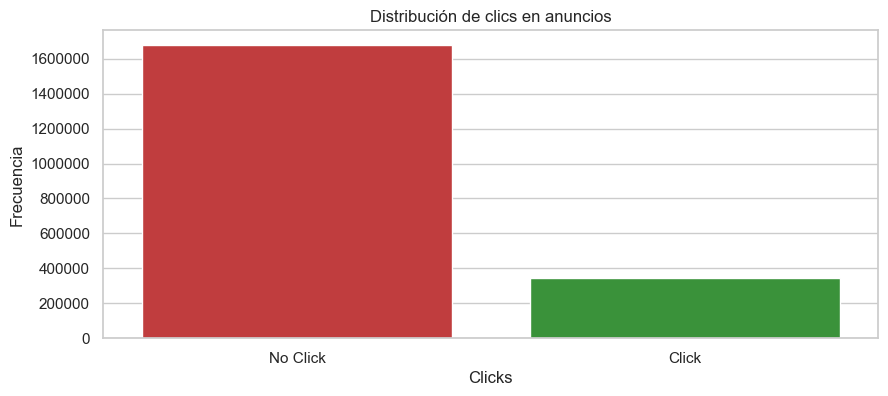

In [20]:
df["click_cat"] = df["click"].map({0: "No Click", 1: "Click"})
sns.countplot(
    x="click_cat",
    data=df,
    palette={"No Click": "#d62728", "Click": "#2ca02c"}
)
plt.ticklabel_format(style="plain", axis="y")
plt.title("Distribución de clics en anuncios")
plt.xlabel("Clicks")
plt.ylabel("Frecuencia")

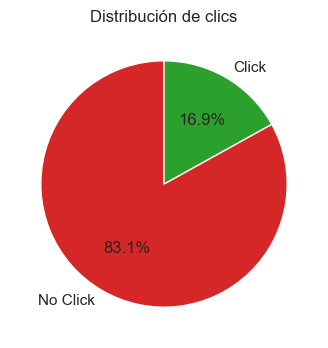

In [50]:
counts = df["click"].value_counts()

plt.pie(
    counts,
    labels=["No Click", "Click"],
    autopct="%1.1f%%",
    colors=["#d62728", "#2ca02c"],
    startangle=90
)

plt.title("Distribución de clics")
plt.show()

Encontramos que la variable objetivo se encuentra claramente desproporcionada, teniendo mas de 16M de casos en los qué no se da click aproximadamente 3.5M millones de casos en los que no se da click a la publicidad generada, podemos decir que si el objetivo de la publicidad generada sea dar click solamente está teniendo un 17% de éxito aproximadamente

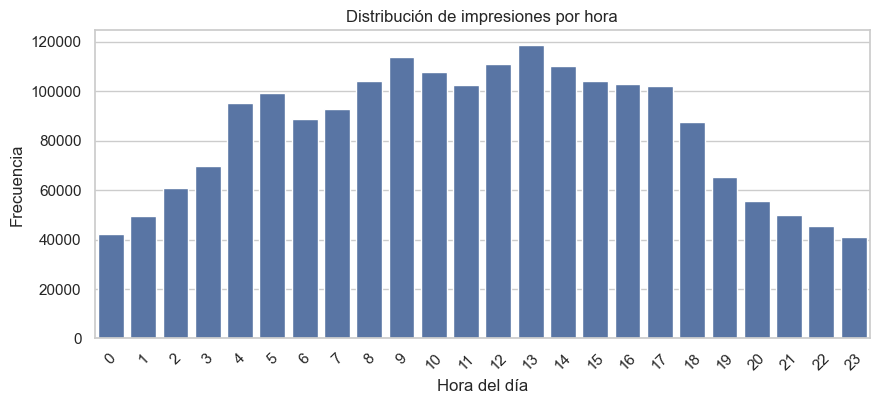

In [26]:
df["hour_day"] = df["hour"] % 100
sns.countplot(x="hour_day", data=df)

plt.xlabel("Hora del día")
plt.ylabel("Frecuencia")
plt.title("Distribución de impresiones por hora")

plt.xticks(rotation=45)
plt.show()

Text(0.5, 1.0, 'Distribución de los dispositivos')

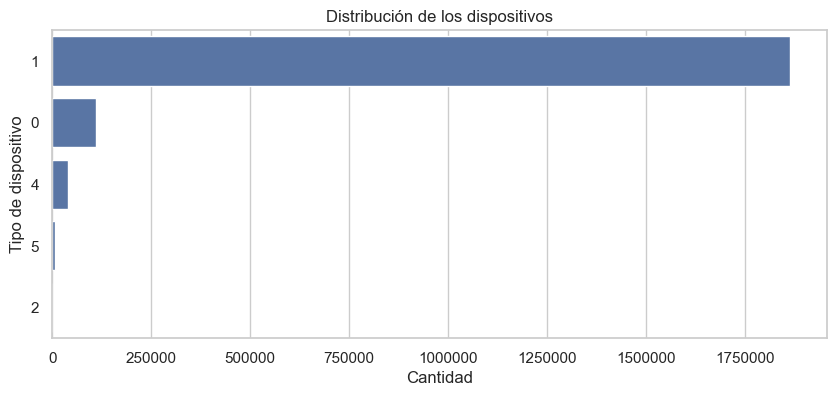

In [49]:
df["dt_cat"] = df["device_type"].map({0: "0", 1: "1", 2: "2", 3: "3", 4: "4", 5: "5"})

sns.countplot(df.dt_cat)
plt.ticklabel_format(style= "plain", axis= "x")
plt.xlabel("Cantidad")
plt.ylabel("Tipo de dispositivo")
plt.title("Distribución de los dispositivos")
